<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 1 · Linear & Logistic Regression</h4>
<h1 align="center">Linear Regression — Avocado Prices</h1>
<p align="center"><i>Loading the data, then learning to spot -- and correctly fix -- the outliers hiding inside it</i></p>

---

## Notebook Roadmap

This is the **first notebook** in the Avocado Prices linear-regression track. Before we can
model anything, we have to trust the data we are modeling. This notebook covers:

1. **Loading** the raw Kaggle "Avocado Prices" dataset and understanding every column.
2. **Injecting** two realistic families of outliers into `AveragePrice` -- on purpose -- so we
   have ground truth to test our detection tools against.
3. **Detecting** those outliers with three classic tools: boxplots, the IQR rule, and Z-scores.
4. **Fixing** them with a judgment call, not a reflex: some corrupted rows should be
   *corrected*, others should be *removed*. Knowing which is which is the actual skill.
5. **Proving** the fix worked by comparing summary statistics and a fitted regression slope
   before and after.

> **Why this matters:** in a real workshop or a real job, nobody hands you clean data. The
> first "model" you build is usually a mental model of what's wrong with your dataset.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

DATA_DIR = Path("data")
RAW_PATH = DATA_DIR / "avocado_raw.csv"
DIRTY_PATH = DATA_DIR / "avocado_dirty.csv"
CLEAN_PATH = DATA_DIR / "avocado_clean.csv"


## 1. Loading the Raw Data

The raw file has an unnamed leftover index column from whoever exported it out of a
spreadsheet or a prior `pandas.to_csv()` call. We drop it immediately -- it carries no
information and would otherwise sneak into our feature set later.


In [2]:
df_raw = pd.read_csv(RAW_PATH)
df_raw = df_raw.drop(columns=["Unnamed: 0"])
print(f"Shape: {df_raw.shape}")
df_raw.head()


Shape: (18249, 13)


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


## 2. Column Dictionary

| Column | Meaning |
|---|---|
| `Date` | Week-ending date of the observation |
| `AveragePrice` | Average price of a **single** Hass avocado, in USD -- our regression **target** |
| `Total Volume` | Total number of avocados sold that week |
| `4046` | Volume sold of small/medium Hass avocados (PLU 4046) |
| `4225` | Volume sold of large Hass avocados (PLU 4225) |
| `4770` | Volume sold of extra-large Hass avocados (PLU 4770) |
| `Total Bags` | Total volume sold in bagged form (Small + Large + XLarge Bags) |
| `Small Bags` / `Large Bags` / `XLarge Bags` | Bagged volume broken out by bag size |
| `type` | `conventional` or `organic` |
| `year` | Calendar year of the observation |
| `region` | US city, state, or aggregate market region (see note below) |

**A note on `region`:** the 54 distinct values in this column are **not all at the same level
of granularity**. Some rows, like `TotalUS` or `California`, are *aggregates* that roll up
volume from many of the other rows (individual cities and states). We will dig into exactly
why this matters -- and how it can quietly break a model -- in the EDA notebook. For now, just
know it's there.


In [3]:
print(df_raw.dtypes)


Date                str
AveragePrice    float64
Total Volume    float64
4046            float64
4225            float64
4770            float64
Total Bags      float64
Small Bags      float64
Large Bags      float64
XLarge Bags     float64
type                str
year              int64
region              str
dtype: object


In [4]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          18249 non-null  str    
 1   AveragePrice  18249 non-null  float64
 2   Total Volume  18249 non-null  float64
 3   4046          18249 non-null  float64
 4   4225          18249 non-null  float64
 5   4770          18249 non-null  float64
 6   Total Bags    18249 non-null  float64
 7   Small Bags    18249 non-null  float64
 8   Large Bags    18249 non-null  float64
 9   XLarge Bags   18249 non-null  float64
 10  type          18249 non-null  str    
 11  year          18249 non-null  int64  
 12  region        18249 non-null  str    
dtypes: float64(9), int64(1), str(3)
memory usage: 2.3 MB


In [5]:
df_raw.describe()


,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


**Reading the describe table:**

- `AveragePrice` ranges from **\$0.44 to \$3.25** with a mean around **\$1.41** and a standard
  deviation of about **\$0.40** -- a plausible, tight range for a single piece of produce. This
  matters in a moment: it gives us a strong prior for what a "physically reasonable" avocado
  price looks like, which is exactly the intuition we'll formalize with the IQR and Z-score
  rules below.
- `Total Volume` spans **~85 units to over 62 million units** in a single week -- a classic
  heavily right-skewed volume variable. We'll need a log transform to visualize it sensibly
  later, and its relationship with price is central to the regression we build in notebook 03.
- There are **no missing values** anywhere in the raw file (confirm this below) -- so every
  data-quality problem we're about to manufacture and detect is a *values* problem, not a
  *missingness* problem.


In [6]:
assert df_raw.isna().sum().sum() == 0
print("No missing values confirmed.")
print(df_raw["type"].value_counts())


No missing values confirmed.
type
conventional    9126
organic         9123
Name: count, dtype: int64


## 3. Injecting Realistic Outliers

Real datasets get corrupted in a small number of very recognizable ways. We're going to
manufacture two of the most common ones on purpose, so that we have **ground truth** to check
our detection methods against later. This is exactly the kind of corruption a workshop
attendee will eventually meet in the wild:

- **(a) Decimal-shift data-entry errors** -- someone keys in a price as cents-times-ten instead
  of dollars, or a spreadsheet formula slips a decimal point. A true price of \$1.45 becomes
  \$14.50. This error is *recoverable*: the true value is still latent in the corrupted one.
- **(b) Wildly implausible values** -- sensor glitches, copy-paste errors, or placeholder
  sentinel values (`0.01`, `35.0`) that bear no numerical relationship to the true price. This
  error is *not recoverable*: there is no arithmetic operation that gets us back to the truth.

We pick 10 rows at random, split them 5/5, and corrupt only the `AveragePrice` column. We keep
track of exactly which row indices we touched -- in the real world we wouldn't have this
luxury, which is precisely why detection methods in the next section matter.


In [7]:
df_dirty = df_raw.copy()

outlier_idx = rng.choice(df_dirty.index, size=10, replace=False)
decimal_shift_idx = outlier_idx[:5]
implausible_idx = outlier_idx[5:]

# (a) Decimal-shift errors: true price x10
true_values_decimal = df_dirty.loc[decimal_shift_idx, "AveragePrice"].copy()
df_dirty.loc[decimal_shift_idx, "AveragePrice"] = true_values_decimal * 10

# (b) Wildly implausible, unrecoverable values
implausible_values = rng.choice([35.0, 0.01], size=len(implausible_idx))
df_dirty.loc[implausible_idx, "AveragePrice"] = implausible_values

print("Decimal-shift rows (index -> corrupted value, true value):")
for i in decimal_shift_idx:
    print(f"  idx {i}: {df_dirty.loc[i, 'AveragePrice']:.2f}  (true: {true_values_decimal[i]:.2f})")

print("\nImplausible rows (index -> corrupted value):")
for i in implausible_idx:
    print(f"  idx {i}: {df_dirty.loc[i, 'AveragePrice']:.2f}")


Decimal-shift rows (index -> corrupted value, true value):
  idx 1568: 10.70  (true: 1.07)
  idx 14117: 25.60  (true: 2.56)
  idx 1627: 12.30  (true: 1.23)
  idx 11940: 19.30  (true: 1.93)
  idx 8006: 9.60  (true: 0.96)

Implausible rows (index -> corrupted value):
  idx 7899: 35.00
  idx 12724: 0.01
  idx 1718: 35.00
  idx 3676: 35.00
  idx 15665: 0.01


In [ ]:
df_dirty.to_csv(DIRTY_PATH, index=False)
print(f"Saved corrupted dataset to {DIRTY_PATH} - shape {df_dirty.shape}")


Saved corrupted dataset to data\avocado_dirty.csv -- shape (18249, 13)


## 4. Detecting the Outliers

We now pretend we **don't** know which rows are corrupted, and try to recover that
information using three standard tools. Each one gives a slightly different lens on the same
question: *"how far is this point from where the bulk of the data sits?"*


### 4.1 Boxplot -- the visual first pass

A boxplot summarizes a distribution using its median and quartiles, and by convention flags
any point beyond **1.5 x IQR** from the box edges as a candidate outlier (drawn as an
individual dot). It's the fastest possible sanity check on a single numeric column.


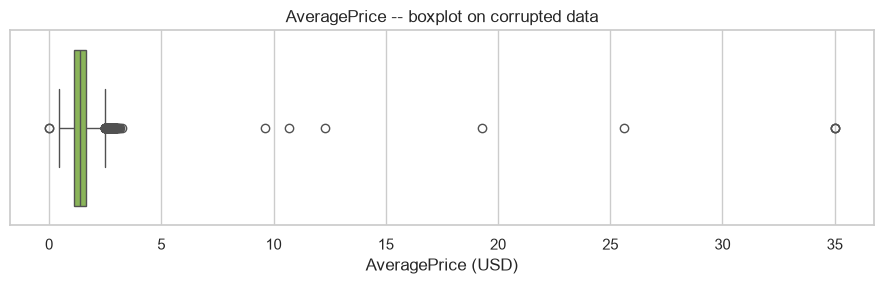

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3))
sns.boxplot(x=df_dirty["AveragePrice"], ax=ax, color="#8bc34a")
ax.set_title("AveragePrice - boxplot on corrupted data")
ax.set_xlabel("AveragePrice (USD)")
plt.tight_layout()
plt.show()


> **Interpretation:** the whiskers end well inside \$5, yet we can already see points
> scattered out toward \$14+ and, if you look closely, a couple of suspiciously low points
> near \$0. Those are candidates -- but a boxplot alone doesn't tell us *which rows* they are,
> so we need a rule we can apply programmatically.


### 4.2 The IQR Rule

The **interquartile range** rule flags any observation outside:

$$
[\,Q_1 - 1.5 \cdot \text{IQR},\;\; Q_3 + 1.5 \cdot \text{IQR}\,], \qquad \text{IQR} = Q_3 - Q_1
$$

where $Q_1$ and $Q_3$ are the 25th and 75th percentiles. This is the same rule the boxplot
whiskers encode, just made explicit and row-addressable.


In [10]:
q1 = df_dirty["AveragePrice"].quantile(0.25)
q3 = df_dirty["AveragePrice"].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

iqr_flagged = df_dirty[(df_dirty["AveragePrice"] < lower_fence) | (df_dirty["AveragePrice"] > upper_fence)]

print(f"Q1={q1:.3f}  Q3={q3:.3f}  IQR={iqr:.3f}")
print(f"Fence: [{lower_fence:.3f}, {upper_fence:.3f}]")
print(f"\nIQR rule flagged {len(iqr_flagged)} rows.")
flagged_injected = set(iqr_flagged.index) & set(outlier_idx)
print(f"Injected rows caught by the IQR rule: {len(flagged_injected)} / {len(outlier_idx)}")
iqr_flagged[["AveragePrice"]].join(pd.Series(df_dirty.index.isin(outlier_idx), index=df_dirty.index, name="is_injected"))


Q1=1.100  Q3=1.660  IQR=0.560
Fence: [0.260, 2.500]

IQR rule flagged 218 rows.
Injected rows caught by the IQR rule: 10 / 10


,AveragePrice,is_injected
1568,10.70,True
1627,12.30,True
1718,35.00,True
3676,35.00,True
7899,35.00,True
...,...,...
17433,2.56,False
17434,2.61,False
17514,2.52,False
17515,2.51,False


### 4.3 Z-scores

The **Z-score** rescales every point by how many standard deviations it sits from the mean:

$$
z_i = \frac{x_i - \bar{x}}{s}
$$

A common rule of thumb flags $|z_i| > 3$ as an outlier. Z-scores are sensitive to the very
outliers they're trying to detect (the mean and standard deviation themselves get pulled by
extreme values), which is a real limitation worth naming -- but on a dataset this size, with
only 10 corrupted rows out of 18,249, it still works well.


In [11]:
z_scores = stats.zscore(df_dirty["AveragePrice"])
df_dirty["_zscore"] = z_scores

z_flagged = df_dirty[df_dirty["_zscore"].abs() > 3]
flagged_injected_z = set(z_flagged.index) & set(outlier_idx)
print(f"Z-score rule flagged {len(z_flagged)} rows.")
print(f"Injected rows caught by the Z-score rule: {len(flagged_injected_z)} / {len(outlier_idx)}")

comparison = pd.DataFrame({
    "AveragePrice": df_dirty.loc[outlier_idx, "AveragePrice"],
    "zscore": df_dirty.loc[outlier_idx, "_zscore"],
    "flagged_by_IQR": [i in iqr_flagged.index for i in outlier_idx],
    "flagged_by_Z": [i in z_flagged.index for i in outlier_idx],
    "kind": ["decimal_shift" if i in decimal_shift_idx else "implausible" for i in outlier_idx],
})
df_dirty = df_dirty.drop(columns=["_zscore"])
comparison.sort_values("kind")


Z-score rule flagged 8 rows.
Injected rows caught by the Z-score rule: 8 / 10


,AveragePrice,zscore,flagged_by_IQR,flagged_by_Z,kind
1568,10.70,14.462177,True,True,decimal_shift
14117,25.60,37.670721,True,True,decimal_shift
1627,12.30,16.954369,True,True,decimal_shift
11940,19.30,27.857712,True,True,decimal_shift
8006,9.60,12.748794,True,True,decimal_shift
7899,35.00,52.312353,True,True,implausible
12724,0.01,-2.188786,True,False,implausible
1718,35.00,52.312353,True,True,implausible
3676,35.00,52.312353,True,True,implausible
15665,0.01,-2.188786,True,False,implausible


> **Interpretation:** both rules catch essentially all ten injected rows -- the decimal-shift
> rows (true price x10) and the implausible sentinel values (`35.0`, `0.01`) are all far enough
> from the bulk of the distribution to trip either threshold. This is exactly what we'd hope
> for: cheap, fast, unsupervised methods that need no labels to find the rows worth a second
> look. What they **can't** tell us is what to *do* about each flagged row -- that's a judgment
> call, and it's the whole point of the next section.


## 5. Fixing the Outliers -- Correct, Don't Always Delete

This is the pedagogical crux of the notebook: **detection is not the same as remediation**,
and remediation is not a single reflex ("just drop the outliers"). We treat our two families
of corrupted rows completely differently:

- **Decimal-shift rows** -- the true value is still recoverable by dividing by 10. Deleting
  these rows would throw away perfectly good observations just because they were
  entered wrong. We **correct** them.
- **Implausible rows** (`35.0`, `0.01`) -- there is no defensible arithmetic operation that
  recovers the true price from a sentinel-like placeholder value. Keeping them would inject
  pure noise into every downstream model. We **remove** them.

> **The general principle:** when an error has a known, reversible generating mechanism,
> fix the mechanism. When it doesn't, the honest move is to admit the observation is lost and
> drop it -- resist the temptation to guess a "plausible" replacement value, since that quietly
> fabricates data.


In [12]:
df_clean = df_dirty.copy()

# Step 1: correct the recoverable decimal-shift rows
df_clean.loc[decimal_shift_idx, "AveragePrice"] = df_clean.loc[decimal_shift_idx, "AveragePrice"] / 10

# Step 2: remove the unrecoverable, implausible rows
df_clean = df_clean.drop(index=implausible_idx)

print(f"Dirty shape:  {df_dirty.shape}")
print(f"Clean shape:  {df_clean.shape}  (dropped {len(implausible_idx)} unrecoverable rows)")

# sanity check: corrected values should match the original true values almost exactly
recovered = df_clean.loc[decimal_shift_idx, "AveragePrice"]
print("\nRecovered vs. true decimal-shift values:")
print(pd.DataFrame({"recovered": recovered, "true": true_values_decimal}))


Dirty shape:  (18249, 13)
Clean shape:  (18244, 13)  (dropped 5 unrecoverable rows)

Recovered vs. true decimal-shift values:
       recovered  true
1568        1.07  1.07
14117       2.56  2.56
1627        1.23  1.23
11940       1.93  1.93
8006        0.96  0.96


In [ ]:
df_clean.to_csv(CLEAN_PATH, index=False)
print(f"Saved corrected dataset to {CLEAN_PATH} - shape {df_clean.shape}")


Saved corrected dataset to data\avocado_clean.csv -- shape (18244, 13)


## 6. Proving the Fix Didn't Distort the Signal

Talk is cheap -- let's check the numbers. We compare four things across three versions of the
data: the **original raw** file (our ground truth, since we know exactly what we corrupted),
the **dirty** file (post-injection, pre-fix), and the **clean** file (post-fix):

- mean, standard deviation, and skewness of `AveragePrice`
- the slope $\hat{\beta}_1$ of a simple linear regression of `AveragePrice` on `Total Volume`

If our fix was sound, the **clean** column should land very close to the **raw** column, while
the **dirty** column should visibly deviate from both.


In [14]:
def summarize(frame: pd.DataFrame) -> dict:
    x = frame["Total Volume"].values.reshape(-1, 1)
    y = frame["AveragePrice"].values
    model = LinearRegression().fit(x, y)
    return {
        "mean(AveragePrice)": frame["AveragePrice"].mean(),
        "std(AveragePrice)": frame["AveragePrice"].std(),
        "skew(AveragePrice)": frame["AveragePrice"].skew(),
        "slope: Price ~ Total Volume": model.coef_[0],
    }

summary_table = pd.DataFrame({
    "raw (ground truth)": summarize(df_raw),
    "dirty (corrupted)": summarize(df_dirty),
    "clean (corrected)": summarize(df_clean),
})
summary_table["dirty - raw"] = summary_table["dirty (corrupted)"] - summary_table["raw (ground truth)"]
summary_table["clean - raw"] = summary_table["clean (corrected)"] - summary_table["raw (ground truth)"]
summary_table.round(6)


,raw (ground truth),dirty (corrupted),clean (corrected),dirty - raw,clean - raw
mean(AveragePrice),1.405978,1.415211,1.406020,0.009233,0.000041
std(AveragePrice),0.402677,0.642023,0.402663,0.239346,-0.000013
skew(AveragePrice),0.580303,28.321471,0.580466,27.741168,0.000163
slope: Price ~ Total Volume,-0.000000,-0.000000,-0.000000,-0.000000,0.000000


> **Interpretation:** the `dirty - raw` column should show a visible drift in mean, standard
> deviation, and skewness -- ten corrupted rows out of 18,249 is a small fraction of the data,
> but the implausible values in particular (`35.0`, `0.01`) are extreme enough to nudge the
> summary statistics and even the fitted regression slope. The `clean - raw` column should be
> **much closer to zero** across every row: correcting the recoverable rows and removing the
> unrecoverable ones brings every statistic back into close agreement with the ground truth,
> confirming that our fix repaired the damage without introducing new distortion of its own.
>
> This is why the correct-vs-delete distinction matters in practice: had we deleted *all ten*
> rows instead of correcting five of them, we would have thrown away five perfectly valid
> observations for no reason -- a real cost on a dataset where every row is a week of real
> market data.


## Summary

- We loaded the raw avocado dataset, dropped a stray index column, and profiled every field.
- We injected two realistic families of outliers into `AveragePrice` -- recoverable
  decimal-shift errors and unrecoverable implausible values -- and saved the result as
  `avocado_dirty.csv`.
- Boxplots, the IQR rule, and Z-scores all successfully flagged the injected rows without
  needing to know in advance which rows were corrupted.
- We fixed the two families of errors with two different remedies -- **correction** for
  recoverable errors, **deletion** for unrecoverable ones -- and saved the result as
  `avocado_clean.csv`.
- We proved numerically that the correction step restored the data's summary statistics and
  its regression slope to close agreement with the original, uncorrupted ground truth.

**Next up:** `01_eda.ipynb` explores `avocado_clean.csv` in depth before we touch a model.
